# Data analysis

In [82]:
import contextlib
import pandas as pd
import polars as pl
from tqdm import tqdm
import os
import random
import numpy as np
import seaborn as sns

In [2]:
SEED = 123456789
os.environ["PYTHONHASHSEED"] = str(SEED)      # deterministic dict order
random.seed(SEED)                            # Python's random
np.random.seed(SEED)

In [3]:
# On simplifie en 8 grands partis d'après https://fr.wikipedia.org/wiki/Liste_des_partis_politiques_en_France_sous_la_Cinqui%C3%A8me_R%C3%A9publique
# On ne code pas tout de suite par un nombre pour pouvoir extraire des sous-graphes
corrections = {
    'non mentionné' : '',
    'indépendant' : '',
    'indépendants' : '',
    'sans étiquette' : '',
    'libre' : '',
    'libres' : '',
    'non inscrits' : '',
    'non inscrit' : '',
    'sans parti politique' : '',
    'hors des partis' : '',
    'abertzale' : '',
    'Fédération nationale des indépendants' : '',
    'Front national' : 'Extrême droite',
    'Rassemblement pour la République' : 'Droite',
    'Union gaulliste pour la démocratie' : 'Droite',
    'Mouvement des gaullistes populaires' : 'Droite',
    'Mouvement solidarité participation' : 'Droite',
    'Parti républicain' : 'Droite',
    'divers droite' : 'Droite',
    'droite' : 'Droite',
    'Centre national des indépendants et paysans' : 'Droite',
    'centre droit' : 'Centre droit', # proche udf en 1988
    'Parti ouvrier européen' : 'Centre droit', # proche udf en 1988
    'Centre des démocrates sociaux' : 'Centre droit',
    'Républicains de progrès' : 'Centre droit',
    'Parti radical' : 'Centre droit',
    'radical' : 'Centre droit',
    'Union pour la démocratie française' : 'Centre droit',
    'Parti radical-socialiste' : 'Centre droit', # pas parti radical de gauche
    'centriste' : 'Centre',
    'centre' : 'Centre',
    'Démocrates de progrès' : 'Centre',
    'centre gauche' : 'Centre gauche',
    'Parti social-démocrate' : 'Centre gauche',
    'Parti démocrate français' : 'Centre gauche',
    'Mouvement des radicaux de gauche' : 'Centre gauche',
    'gauche' : 'Gauche',
    'socialiste' : 'Gauche',
    'socialistes' : 'Gauche',
    'Humaniste' : 'Gauche',
    'Parti humaniste' : 'Gauche',
    'Parti socialiste' : 'Gauche',
    'Parti socialiste unifié' : 'Gauche',
    'Mouvement rouge et vert' : 'Gauche',
    'Comités d\'initiative pour une nouvelle politique à gauche' : 'Gauche',
    'Parti communiste français' : 'Gauche',
    'Parti communiste réunionnais' : 'Gauche',
    'Parti communiste guadeloupéen' : 'Gauche',
    'Verts alternatifs' : 'Verts',
    'Parti vert' : 'Verts',
    'Jura écologie' : 'Verts',
    'vert indépendant' : 'Verts',
    'Mouvement écologique' : 'Verts',
    'Anjou écologie autogestion' : 'Verts',
    'Comités Juquin' : 'Extrême gauche' # LCR
}

In [4]:
# On introduit un index de position
index_position = {
    'Extrême droite' : 1.,    'Droite' : 0.8,
    'Centre droit' : 0.6,    'Centre gauche' : 0.4,
    'Gauche' : 0.2, 'Extrême gauche':0., 'Centre':0.5, 'Verts':0.4, '':None
}

In [11]:
df = pl.read_parquet("df_gliner_full.parquet").with_columns(
    pl.col("titulaire-soutien")
        .str.split(";")
        .map_elements(lambda l: l.replace_strict(corrections,default="").unique(), pl.List(pl.String))
        .alias("titulaire-soutien-list")
).with_columns(
    pl.col("titulaire-soutien-list")
        .map_elements(lambda l: l.replace_strict(index_position,default=float("nan")).mean(), pl.Float64)
        .alias("titulaire-soutien-position")
).filter(pl.col("titulaire-soutien-position").is_not_null())
df.select(pl.col("titulaire-soutien-list"),pl.col("titulaire-soutien-position"))

titulaire-soutien-list,titulaire-soutien-position
list[str],f64
"[""Extrême droite""]",1.0
"[""Extrême gauche""]",0.0
"[""Droite"", ""Centre droit""]",0.7
"[""Gauche""]",0.2
"[""Gauche""]",0.2
…,…
"[""Droite"", """", ""Centre droit""]",0.7
"[""Gauche""]",0.2
"[""Gauche""]",0.2


# Descriptive statistics

In [33]:
print(df.get_column("titulaire-nom-positions").list.len().sum())
df.get_column("titulaire-nom-positions").list.len().value_counts().sort("titulaire-nom-positions")

5140


titulaire-nom-positions,count
u32,u32
1,277
2,1077
3,316
4,159
5,56
…,…
15,3
16,2
17,1


In [37]:
df.select(
    pl.col("titulaire-nom"),
    pl.col("titulaire-nom-positions").list.len().alias("Nb")
).filter(pl.col("Nb") > 15)

titulaire-nom,Nb
str,u32
"""Waline""",18
"""Durr""",18
"""Klifa""",25
"""Bouvet""",16
"""Richard""",16
"""Bouvet""",17


In [52]:
df.get_column("titulaire-nom-positions").list.len().describe(percentiles=0.9)

statistic,value
str,f64
"""count""",1986.0
"""null_count""",0.0
"""mean""",2.588117
"""std""",1.7828
"""min""",1.0
"""90%""",4.0
"""max""",25.0


In [55]:
df.select(
    pl.col("titulaire-nom"),
    pl.col("titulaire-nom-positions").list.len().alias("Nb")
).filter(pl.col("Nb") > 10).get_column("Nb").sum()
# 

227

In [42]:
list(map(lambda x: print(x["transcript"]), df.filter(pl.col("titulaire-nom")=="Klifa").iter_rows(named=True)))

LE SENS DE L'ACTION
1965 : Joseph KLIFA rejoint l'équipe municipale d'Emile MULLER 1973 : Joseph KLIFA est élu Conseiller Régional d'Alsace 1981 : Joseph KLIFA devient Maire de Mulhouse 1983 : Joseph KLIFA est réélu Maire 1986 : Joseph KLIFA est élu à l'Assemblée Nationale Il participe activement au travail de la Commission des Lois : il se bat en haut lieu pour la défense des dossiers alsaciens. Demain, ce sens de l'action, cette efficacité en plus, seront au service des cantons de MULHOUSE EST, MULHOUSE OUEST et MULHOUSE SUD dont les communes de : BRUEBACH, BRUNSTATT, DIDENHEIM, FLAXLANDEN, GALFINGUE, HEIMSBRUNN, MORSCHWILLER-LE-BAS, ZILLISHEIM.
l'efficacité en plus
Jest vital que notre Région, notre Pays retrouvent le sens -des valeurs démocratiques et républicaines.
Avec moi, si vous le coulz, défendez la Liberte; l'égalité et la Fraternité, dans le respect des droits et des devoirs de tous ceux qui veulent vivre dans la paix sociale en écoutant la démagogie et les promesses jamais

[None, None]

In [59]:
(df.select(
    pl.col("titulaire-nom-positions").list.len().alias("Number of repeats"),
    (pl.when(pl.col("titulaire-soutien-position") < 0.5)).then(pl.lit("Left")).otherwise(pl.lit("Right")).alias("Affiliation")
).select(pl.struct(["Number of repeats","Affiliation"]).alias("s")).get_column("s").value_counts()
.unnest("s").sort(["Number of repeats","Affiliation"])
.pivot("Affiliation", index="Number of repeats", values="count", aggregate_function='sum')
)

Number of repeats,Left,Right
u32,u32,u32
1,156,121
2,374,703
3,160,156
4,84,75
5,24,32
…,…,…
15,1,2
16,1,1
17,0,1


# Prepare analysis of entities

In [60]:
df = df.unnest("res").explode("titulaire-nom-positions")
df.select(pl.selectors.by_name("titulaire-nom","titulaire-nom-positions","person","entities","political ideology"))

titulaire-nom,titulaire-nom-positions,person,entities,political ideology
str,i64,list[struct[2]],struct[7],str
"""Aulagne""",1240,"[{{""François MITTERRAND"",523,542},""right""}, {null,""right""}]","{[{""Bernard AULAGNE"",1232,1247}, {""François MITTERRAND"",523,542}],[],[],[],[],[{""RPR"",2273,2276}, {""UDF"",614,617}, … {""PS"",2283,2285}],[{""Ain"",1389,1392}, {""France"",2774,2780}]}","""right"""
"""Aulagne""",2866,"[{{""François MITTERRAND"",523,542},""right""}, {null,""right""}]","{[{""Bernard AULAGNE"",1232,1247}, {""François MITTERRAND"",523,542}],[],[],[],[],[{""RPR"",2273,2276}, {""UDF"",614,617}, … {""PS"",2283,2285}],[{""Ain"",1389,1392}, {""France"",2774,2780}]}","""right"""
"""Pujol""",208,"[{{""JUQUIN"",193,199},""left""}, {{""PUJOL"",208,213},""right""}]","{[{""JUQUIN"",1472,1478}, {""PUJOL"",208,213}],[{""GAUCHE"",3479,3485}, {""JUQUIN"",193,199}],[{""PUJOL"",208,213}, {""Jean-François MORTEL"",744,764}],[],[],[{""CEVIPOF"",1707,1714}, {""CEVIPOFSciences"",1680,1695}, … {""Sciences Po"",1660,1671}],[{""Afrique"",496,503}]}","""left"""
"""Pujol""",3567,"[{{""JUQUIN"",193,199},""left""}, {{""PUJOL"",208,213},""right""}]","{[{""JUQUIN"",1472,1478}, {""PUJOL"",208,213}],[{""GAUCHE"",3479,3485}, {""JUQUIN"",193,199}],[{""PUJOL"",208,213}, {""Jean-François MORTEL"",744,764}],[],[],[{""CEVIPOF"",1707,1714}, {""CEVIPOFSciences"",1680,1695}, … {""Sciences Po"",1660,1671}],[{""Afrique"",496,503}]}","""left"""
"""Boyon""",155,"[{{""Jacques BOYON"",147,160},""left""}, {{""Paul MORIN"",320,330},""left""}, {{""Jacques CHIRAC"",1745,1759},""right""}]","{[{""Paul MORIN"",4294,4304}, {""Jacques BOYON"",147,160}, {""Jacques CHIRAC"",1745,1759}],[],[{""Paul MORIN"",320,330}],[],[],[{""Assemblée Nationale"",807,826}, {""CEVIPOF"",20,27}, … {""Légion d'honneur"",273,289}],[{""BRESSE"",3598,3604}, {""BOURG"",3538,3543}, {""REVERMONT"",2998,3007}]}","""left"""
…,…,…,…,…
"""Hoarau""",5,"[{{""Élie HOARAU"",0,11},""right""}]","{[{""Élie HOARAU"",3689,3700}, {""Wilfrid Bertile"",636,651}],[],[{""Monsieur Pihouée"",733,749}],[],[],[{""CEVIPOF"",2154,2161}, {""République"",1345,1355}, {""CEVIPOFSciences"",2127,2142}],[{""Paris"",1757,1762}, {""France"",1485,1491}]}","""right"""
"""Hoarau""",3694,"[{{""Élie HOARAU"",0,11},""right""}]","{[{""Élie HOARAU"",3689,3700}, {""Wilfrid Bertile"",636,651}],[],[{""Monsieur Pihouée"",733,749}],[],[],[{""CEVIPOF"",2154,2161}, {""République"",1345,1355}, {""CEVIPOFSciences"",2127,2142}],[{""Paris"",1757,1762}, {""France"",1485,1491}]}","""right"""
"""Vergès""",33,"[{{""Paul VERGÈS"",28,39},""right""}, {{""Jean-Paul Virapoullé"",595,615},""right""}, {{""Jean-Claude Fruteau"",1121,1140},""left""}]","{[{""Paul Vergès"",1400,1411}, {""Lucet LANGENIER"",3746,3761}, … {""Jean-Paul Virapoulé"",1670,1689}],[],[{""Jean-Paul Virapoulé"",1670,1689}, {""Jean-Paul Virapoullé"",595,615}, {""Jean-Claude Fruteau"",1121,1140}],[],[],[{""Assemblée Nationale"",1806,1825}, {""Sciences Po / fonds CEVIPOF"",0,27}],[{""Paris"",2035,2040}]}","""left"""


In [61]:
def position_is_inside_span(pos:int, span):
    # Returns a boolean
    # True if position is inside the span
    return (pos >= span["start"]) & (pos < span["end"])

df = df.unnest("entities").with_columns(
    pl.struct(["titulaire-nom-positions","PER"])
    .map_elements(lambda s: any([position_is_inside_span(s["titulaire-nom-positions"],span) for span in s["PER"]]), 
                  return_dtype=pl.Boolean)
    .alias("is-in-PER"),
    pl.struct(["titulaire-nom-positions","PER_LEFT"])
    .map_elements(lambda s: any([position_is_inside_span(s["titulaire-nom-positions"],span) for span in s["PER_LEFT"]]), 
                  return_dtype=pl.Boolean)
    .alias("is-in-PER_LEFT"),
    pl.struct(["titulaire-nom-positions","PER_RIGHT"])
    .map_elements(lambda s: any([position_is_inside_span(s["titulaire-nom-positions"],span) for span in s["PER_RIGHT"]]), 
                  return_dtype=pl.Boolean)
    .alias("is-in-PER_RIGHT"),
    pl.struct(["titulaire-nom-positions","PER_GAUCHE"])
    .map_elements(lambda s: any([position_is_inside_span(s["titulaire-nom-positions"],span) for span in s["PER_GAUCHE"]]), 
                  return_dtype=pl.Boolean)
    .alias("is-in-PER_GAUCHE"),
    pl.struct(["titulaire-nom-positions","PER_DROITE"])
    .map_elements(lambda s: any([position_is_inside_span(s["titulaire-nom-positions"],span) for span in s["PER_DROITE"]]), 
                  return_dtype=pl.Boolean)
    .alias("is-in-PER_DROITE"),
    pl.struct(["titulaire-nom-positions","ORG"])
    .map_elements(lambda s: any([position_is_inside_span(s["titulaire-nom-positions"],span) for span in s["ORG"]]), 
                  return_dtype=pl.Boolean)
    .alias("is-in-ORG"),
    pl.struct(["titulaire-nom-positions","LOC"])
    .map_elements(lambda s: any([position_is_inside_span(s["titulaire-nom-positions"],span) for span in s["LOC"]]), 
                  return_dtype=pl.Boolean)
    .alias("is-in-LOC")
)


In [62]:
df.select(pl.selectors.by_name("titulaire-nom","titulaire-nom-positions","is-in-PER","PER","is-in-PER_LEFT"))

titulaire-nom,titulaire-nom-positions,is-in-PER,PER,is-in-PER_LEFT
str,i64,bool,list[struct[3]],bool
"""Aulagne""",1240,true,"[{""Bernard AULAGNE"",1232,1247}, {""François MITTERRAND"",523,542}]",false
"""Aulagne""",2866,false,"[{""Bernard AULAGNE"",1232,1247}, {""François MITTERRAND"",523,542}]",false
"""Pujol""",208,true,"[{""JUQUIN"",1472,1478}, {""PUJOL"",208,213}]",false
"""Pujol""",3567,false,"[{""JUQUIN"",1472,1478}, {""PUJOL"",208,213}]",false
"""Boyon""",155,true,"[{""Paul MORIN"",4294,4304}, {""Jacques BOYON"",147,160}, {""Jacques CHIRAC"",1745,1759}]",false
…,…,…,…,…
"""Hoarau""",5,false,"[{""Élie HOARAU"",3689,3700}, {""Wilfrid Bertile"",636,651}]",false
"""Hoarau""",3694,true,"[{""Élie HOARAU"",3689,3700}, {""Wilfrid Bertile"",636,651}]",false
"""Vergès""",33,false,"[{""Paul Vergès"",1400,1411}, {""Lucet LANGENIER"",3746,3761}, … {""Jean-Paul Virapoulé"",1670,1689}]",false


# Results and discussion

## PER, LOC, ORG tasks

In [70]:
def recall_table_for_column(df,col_name:str):
    return (df.with_columns(weight=1).select(pl.sum(col_name,"weight"))
        .with_columns(recall = pl.col(col_name)/pl.col("weight"))
        .select(pl.selectors.by_name(col_name,"weight","recall")))

In [71]:
recall_table_for_column(df,"is-in-PER")

is-in-PER,weight,recall
u32,i32,f64
1886,5140,0.366926


In [72]:
recall_table_for_column(df,"is-in-LOC")

is-in-LOC,weight,recall
u32,i32,f64
5,5140,0.000973


In [73]:
recall_table_for_column(df,"is-in-ORG")

is-in-ORG,weight,recall
u32,i32,f64
2,5140,0.000389


In [79]:
df.filter(pl.col("is-in-LOC") | pl.col("is-in-ORG")).select(pl.col("titulaire-nom"))

titulaire-nom
str
"""Kuster"""
"""Casanova"""
"""Falco"""
"""Deau"""
"""Perbet"""
"""Vuillaume"""
"""Rochebloine"""


## Classification task
We compute the distributions of the position index in the classifications

<Axes: xlabel='titulaire-soutien-position', ylabel='Count'>

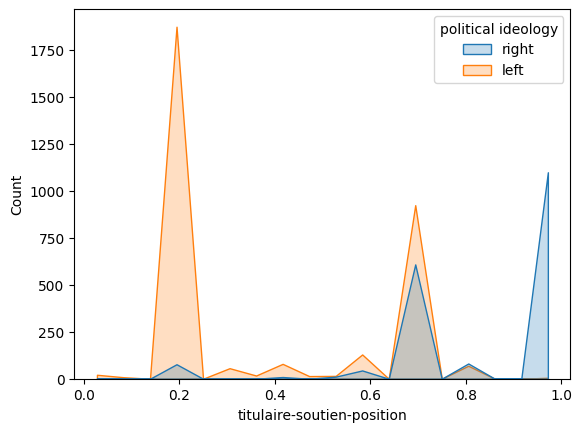

In [83]:
df_pandas = df.to_pandas()
sns.histplot(data=df_pandas, 
             x="titulaire-soutien-position", 
             hue="political ideology", element="poly")

In [ ]:
toto = df.get_column("is-in-PER").value_counts().rows_by_key("is-in-PER", unique=True)

In [ ]:
df.with_columns(weight=1).group_by(
    pl.col("titulaire-nom"),maintain_order=True
).agg(
    pl.col("is-in-PER").sum().alias("toto"),
    pl.col("weight").sum().alias("total")
).with_columns(
    recall = pl.col("toto")/pl.col("total")
).select(pl.selectors.by_name("titulaire-nom","toto","total","recall"))

In [ ]:
df[0]["entities"]["PER"]